# Comparing the main models:

### Latent-Evolution–Operator (LEO) Models: Unified View

We view the parametric time–stepper as an evolution operator
$$
\mathfrak{T}_\zeta : u(x,t,\zeta) \mapsto u(x,t+\tau,\zeta),
$$
and approximate it on a low–dimensional manifold via an encoder \(E\), decoder \(D\), and latent propagator \(P\):
$$
z_t = E(u(x,t)),\qquad \hat z_{t+\tau} = P(z_t,\tau,\zeta),\qquad \hat u(x,t+\tau) = D(\hat z_{t+\tau}).
$$

The training objective is built from four terms:
$$
\begin{aligned}
L_{\text{rec}}  &= \lVert u(x,t)   - D(E(u(x,t))) \rVert_2^2\\
L_{\text{dir}}  &= \lVert u(x,t+\tau) - \hat u(x,t+\tau) \rVert_2^2
               = \lVert u(x,t+\tau) - D(P(E(u(x,t)),\tau,\zeta)) \rVert_2^2, \\
L_{\text{align}} &= \lVert P(E(u(x,t)),\tau,\zeta) - E(u(x,t+\tau)) \rVert_2^2, \\
L_{\text{KL}}   &= \mathrm{KL}\!\big(q(z\mid u(x,t))\;\Vert\;\mathcal{N}(0,I)\big)
\end{aligned}
$$

All variants use the unified loss
$$
L = L_{\text{rec}}
  + \lambda_{\text{dir}}   L_{\text{dir}}
  + \lambda_{\text{align}} L_{\text{align}}
  + \beta L_{\text{KL}} .
$$

**Model choices (by coefficients):**

- **Direct LEO (D-LEO-AE):** $$(\lambda_{\text{dir}}>0,\ \lambda_{\text{align}}=0,\ \beta=0)$$
- **Consistent(Align) LEO (A-LEO-AE):** $$(\lambda_{\text{dir}}=0,\ \lambda_{\text{align}}>0,\ \beta=0)$$
- **Hybrid LEO (H-LEO-AE):** $$(\lambda_{\text{dir}}>0,\ \lambda_{\text{align}}>0,\ \beta=0)$$
- **VAE LEO (D-LEO-VAE):** $$(\lambda_{\text{dir}}>0,\ \lambda_{\text{align}}=0,\ \beta>0)$$


In [1]:
# Importing the packages:
import os
import torch
import time
import random
import warnings
import numpy as np
import torch.nn as nn
from tqdm import tqdm
import matplotlib.cm as cm
from model_io import load_model
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import mean_squared_error
from data import load_from_path, ReDataset, exact_solution
from LEO_models import Encoder, Decoder, Propagator, VAE

# loading the intervals - 
data_path = "./data"
dataset_train, dataset_val, re_interval_split, tau_interval_split = load_from_path(data_path)

# Instantiate
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Dataloder (train only, as requested)
def get_data_loader(dataset, batch_size):
    data = list(zip(dataset.X, dataset.X_tau, dataset.t_values, dataset.tau_values, dataset.Re_values))
    data = data[: len(data) - len(data) % batch_size]
    return DataLoader(data, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)

BATCH_SIZE = 128
train_loader = get_data_loader(dataset_train, batch_size=BATCH_SIZE)
val_loader   = get_data_loader(dataset_val, batch_size=BATCH_SIZE)

mse = nn.MSELoss()

# Loading the architectures
encoder = Encoder().to(DEVICE)
decoder = Decoder().to(DEVICE)
model   = VAE(encoder, decoder).to(DEVICE)

# Loading the Propagator:
propagator = Propagator().to(DEVICE)


# Loading the best checkpoints for different LEO variants
ckpt_d_leo_ae = torch.load("./Best_D_LEO.pt", map_location="cuda")  # Best Direct Model
ckpt_c_leo_ae = torch.load("./Best_C_LEO.pt", map_location="cuda")  # Best Consistent Model (was Align)
ckpt_h_leo_ae = torch.load("./Best_H_LEO.pt", map_location="cuda")  # Best Hybrid Model
leo_d_vae_pth = "./Best_D_LEO_VAE.pt"


from LEO_models import Encoder, Decoder, Propagator

class LEOWrapper(nn.Module):
    def __init__(self, encoder, decoder, propagator):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.propagator = propagator

    def forward(self, x, tau, Re):
        # x: (B,128) or (128,)
        if x.dim() == 1:
            x = x.unsqueeze(0)

        if tau.dim() == 1:
            tau = tau.unsqueeze(1)
        if Re.dim() == 1:
            Re = Re.unsqueeze(1)

        # encode-decode at t
        z_t = self.encoder(x)
        x_hat_t = self.decoder(z_t)

        # propagate + decode
        z_prop = self.propagator(z_t, tau, Re)
        x_hat_tau_prop = self.decoder(z_prop)

        return x_hat_t, z_t, z_prop, x_hat_tau_prop


def load_leo_model_from_ckpt(ckpt_or_path, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Accept str/Path or dict
    if isinstance(ckpt_or_path, (str, os.PathLike)):
        ckpt = torch.load(ckpt_or_path, map_location=device)
    elif isinstance(ckpt_or_path, dict):
        ckpt = ckpt_or_path
    else:
        raise TypeError(f"ckpt_or_path must be filepath or dict, got {type(ckpt_or_path)}")

    # Instantiate fresh modules
    encoder = Encoder().to(device)
    decoder = Decoder().to(device)
    propagator = Propagator().to(device)

    # Load weights (handle both naming schemes)
    if "encoder" in ckpt:
        encoder.load_state_dict(ckpt["encoder"])
    if "decoder" in ckpt:
        decoder.load_state_dict(ckpt["decoder"])
    if "propagator" in ckpt:
        propagator.load_state_dict(ckpt["propagator"])

    # older VAE-style:
    if "state_dict_vae" in ckpt:
        vae_sd = ckpt["state_dict_vae"]
        encoder.load_state_dict(
            {k.replace("encoder.", ""): v for k, v in vae_sd.items() if k.startswith("encoder.")},
            strict=False
        )
        decoder.load_state_dict(
            {k.replace("decoder.", ""): v for k, v in vae_sd.items() if k.startswith("decoder.")},
            strict=False
        )

    if "state_dict_prop" in ckpt and "propagator" not in ckpt:
        propagator.load_state_dict(ckpt["state_dict_prop"])

    wrapper = LEOWrapper(encoder, decoder, propagator).to(device)
    wrapper.eval()
    return wrapper


# Load wrapper from checkpoint
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Loading the models:
leo_d_ae = load_leo_model_from_ckpt(ckpt_d_leo_ae, device=device)
leo_c_ae = load_leo_model_from_ckpt(ckpt_c_leo_ae, device=device)  # Consistent
leo_h_ae = load_leo_model_from_ckpt(ckpt_h_leo_ae, device=device)

leo_d_ae.eval(); leo_c_ae.eval(); leo_h_ae.eval();


# Loading for the direct LEO with VAE backbone (model_v2)
from model_io import load_model
from model_v2 import Encoder, Decoder, Propagator_concat as Propagator_C, Model as leo_d_vae

def get_model(input_dim, latent_dim, Propagator):
    encoder = Encoder(input_dim, latent_dim)
    decoder = Decoder(latent_dim, input_dim)
    propagator = Propagator(latent_dim)
    model = leo_d_vae(encoder, decoder, propagator)
    return model

def load_model_weights(model, checkpoint_path):
    if not os.path.isfile(checkpoint_path):
        print(f"Checkpoint file not found at path: {checkpoint_path}")
        return model

    try:
        checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))
    except Exception as e:
        print(f"Error loading checkpoint from {checkpoint_path}: {e}")
        return model

    state_dict = checkpoint.get("model_state_dict", checkpoint)
    model.load_state_dict(state_dict, strict=False)
    model.eval()
    return model

device = "cuda" if torch.cuda.is_available() else "cpu"
leo_d_vae_model = get_model(128, 2, Propagator_C)
leo_d_vae_model = load_model_weights(leo_d_vae_model, leo_d_vae_pth).to(device)
leo_d_vae_model.eval();

# Predict function builders
def make_predict_fn_leo_wrapper(leo_model, device):
    """
    For AE-based LEO models wrapped by LEOWrapper.
    Input:  Re_val (float), tau_val (float), x_t (np.array [128])
    Output: predicted x(t+tau) as np.array [128]
    """
    def predict_fn(Re_val, tau_val, x_t):
        x = torch.tensor(x_t, dtype=torch.float32, device=device)          # (128,)
        tau = torch.tensor([tau_val], dtype=torch.float32, device=device)  # (1,)
        Re  = torch.tensor([Re_val],  dtype=torch.float32, device=device)  # (1,)

        leo_model.eval()
        with torch.no_grad():
            _, _, _, x_hat_tau = leo_model(x, tau, Re)

        return x_hat_tau.squeeze().detach().cpu().numpy()
    return predict_fn


def make_predict_fn_leo_d_vae(leo_d_vae_model, device):
    """
    For Direct LEO with VAE backbone (model_v2).
    Assumes forward(x_t, tau, Re) returns:
        x_hat_t, x_hat_tau, *rest
    """
    def predict_fn(Re_val, tau_val, x_t):
        x_t_tensor = torch.tensor(x_t, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)  # (1,1,128)
        tau_tensor = torch.tensor([[tau_val]], dtype=torch.float32, device=device)  # (1,1)
        Re_tensor  = torch.tensor([[Re_val]],  dtype=torch.float32, device=device)  # (1,1)

        leo_d_vae_model.eval()
        with torch.no_grad():
            x_hat_t, x_hat_tau, mean, log_var, z_tau = leo_d_vae_model(x_t_tensor, tau_tensor, Re_tensor)

        return x_hat_tau.squeeze().detach().cpu().numpy()
    return predict_fn


# Build predict_fns dict for all four models (names updated)
predict_fns = {
    "D-LEO-AE":   make_predict_fn_leo_wrapper(leo_d_ae, device),
    "C-LEO-AE":   make_predict_fn_leo_wrapper(leo_c_ae, device),  # was A- (Align)
    "H-LEO-AE":   make_predict_fn_leo_wrapper(leo_h_ae, device),
    "D-LEO-VAE":  make_predict_fn_leo_d_vae(leo_d_vae_model, device),
}

In [2]:
from sklearn.metrics import mean_squared_error

@torch.no_grad()
def evaluate_models_on_grid(
    re_interval_split,
    tau_interval_split,
    exact_solution,
    dt,
    model_predict_fns,
    n_samples=1000,
    t_range=(0.0, 2.0),
):
    """
    Evaluate multiple models on the 3x3 (Re, tau) grid.

    Returns
    -------
    mse_by_model: dict[model_name][zone_key] = avg MSE
      where zone_key in:
        'Re_left-tau_left', 'Re_left-tau_interp', ..., 'Re_right-tau_right'
    """

    # Representative points for each region (fixed for reproducibility per call)
    Re_left   = float(np.random.uniform(*re_interval_split.extrapolation_left))
    Re_interp = float(np.random.uniform(*re_interval_split.interpolation))
    Re_right  = float(np.random.uniform(*re_interval_split.extrapolation_right))

    tau_left   = float(np.random.uniform(*tau_interval_split.extrapolation_left))
    tau_interp = float(np.random.uniform(*tau_interval_split.interpolation))
    tau_right  = float(np.random.uniform(*tau_interval_split.extrapolation_right))

    combos = [
        (Re_left,   tau_left),
        (Re_left,   tau_interp),
        (Re_left,   tau_right),
        (Re_interp, tau_left),
        (Re_interp, tau_interp),
        (Re_interp, tau_right),
        (Re_right,  tau_left),
        (Re_right,  tau_interp),
        (Re_right,  tau_right),
    ]

    def zone_label(Re_val, tau_val):
        # uses identity with the chosen reps above
        if Re_val == Re_left:
            re_lab = "left"
        elif Re_val == Re_interp:
            re_lab = "interp"
        else:
            re_lab = "right"

        if tau_val == tau_left:
            tau_lab = "left"
        elif tau_val == tau_interp:
            tau_lab = "interp"
        else:
            tau_lab = "right"

        return f"Re_{re_lab}-tau_{tau_lab}"

    model_names = list(model_predict_fns.keys())
    mse_sums = {m: {} for m in model_names}
    counts   = {m: {} for m in model_names}

    # init accumulators for each zone
    for Re_val, tau_val in combos:
        zkey = zone_label(Re_val, tau_val)
        for m in model_names:
            mse_sums[m][zkey] = 0.0
            counts[m][zkey]   = 0

    # sampling loop
    for Re_val, tau_val in combos:
        zkey = zone_label(Re_val, tau_val)

        for _ in range(n_samples):
            t = np.random.uniform(*t_range)

            x_t       = np.asarray(exact_solution(Re_val, t))
            x_tau_gt  = np.asarray(exact_solution(Re_val, t + tau_val * dt))

            for mname, predict_fn in model_predict_fns.items():
                x_tau_pred = np.asarray(predict_fn(Re_val, tau_val, x_t))
                err = mean_squared_error(x_tau_gt, x_tau_pred)

                mse_sums[mname][zkey] += err
                counts[mname][zkey]   += 1

    # average MSEs
    mse_by_model = {m: {} for m in model_names}
    for m in model_names:
        for zkey in mse_sums[m]:
            n = max(1, counts[m][zkey])
            mse_by_model[m][zkey] = mse_sums[m][zkey] / n

    # print
    for m in model_names:
        print(f"\nMSE Results for {m}:")
        for zkey, val in mse_by_model[m].items():
            print(f"  {zkey}: {val:.4e}")

    return mse_by_model

## Errors over the validation zones

In [3]:
from sklearn.metrics import mean_squared_error

@torch.no_grad()
def evaluate_models_on_grid(
    re_interval_split,
    tau_interval_split,
    exact_solution,
    dt,
    model_predict_fns,
    n_samples=1000,
    t_range=(0.0, 2.0),
):
    """
    Evaluate multiple models on the 3x3 (Re, tau) grid.

    For each of the 9 zones, we draw `n_samples` random triples
    (Re, tau, t_init) with:
        Re  ~ Uniform(Re_zone_min, Re_zone_max)
        tau ~ Uniform(tau_zone_min, tau_zone_max)
        t   ~ Uniform(t_range[0], t_range[1])

    Returns
    -------
    mse_by_model: dict[model_name][zone_key] = avg MSE
      where zone_key in:
        'Re_left-tau_left', 'Re_left-tau_interp', ..., 'Re_right-tau_right'
    """

    # Define the three Re and tau sub-intervals
    re_map = {
        "left":   re_interval_split.extrapolation_left,
        "interp": re_interval_split.interpolation,
        "right":  re_interval_split.extrapolation_right,
    }
    tau_map = {
        "left":   tau_interval_split.extrapolation_left,
        "interp": tau_interval_split.interpolation,
        "right":  tau_interval_split.extrapolation_right,
    }

    re_parts  = ["left", "interp", "right"]
    tau_parts = ["left", "interp", "right"]

    model_names = list(model_predict_fns.keys())

    # Initialize accumulators
    mse_sums = {m: {} for m in model_names}
    counts   = {m: {} for m in model_names}

    for r_part in re_parts:
        for t_part in tau_parts:
            zkey = f"Re_{r_part}-tau_{t_part}"
            for m in model_names:
                mse_sums[m][zkey] = 0.0
                counts[m][zkey]   = 0

    # Sampling loop: for each zone, draw n_samples random (Re, tau, t_init)
    for r_part in re_parts:
        Re_min, Re_max = re_map[r_part]
        for t_part in tau_parts:
            tau_min, tau_max = tau_map[t_part]
            zkey = f"Re_{r_part}-tau_{t_part}"

            for _ in range(n_samples):
                Re_val  = float(np.random.uniform(Re_min, Re_max))
                tau_val = float(np.random.uniform(tau_min, tau_max))
                t       = float(np.random.uniform(*t_range))

                # ground-truth solution
                x_t      = np.asarray(exact_solution(Re_val, t))
                x_tau_gt = np.asarray(exact_solution(Re_val, t + tau_val * dt))

                # loop over models
                for mname, predict_fn in model_predict_fns.items():
                    x_tau_pred = np.asarray(predict_fn(Re_val, tau_val, x_t))
                    err = mean_squared_error(x_tau_gt, x_tau_pred)

                    mse_sums[mname][zkey] += err
                    counts[mname][zkey]   += 1

    # Average MSEs
    mse_by_model = {m: {} for m in model_names}
    for m in model_names:
        print(f"\nMSE Results for {m}:")
        for r_part in re_parts:
            for t_part in tau_parts:
                zkey = f"Re_{r_part}-tau_{t_part}"
                n = max(1, counts[m][zkey])
                avg = mse_sums[m][zkey] / n
                mse_by_model[m][zkey] = avg
                print(f"  {zkey}: {avg:.4e}")

    return mse_by_model


MSE Results for D-LEO-AE:
  Re_left-tau_left: 3.0818e-05
  Re_left-tau_interp: 5.9403e-05
  Re_left-tau_right: 2.7897e-04
  Re_interp-tau_left: 3.5203e-05
  Re_interp-tau_interp: 2.6616e-07
  Re_interp-tau_right: 1.7954e-07
  Re_right-tau_left: 6.2516e-05
  Re_right-tau_interp: 5.2071e-07
  Re_right-tau_right: 3.0995e-07

MSE Results for C-LEO-AE:
  Re_left-tau_left: 3.0730e-04
  Re_left-tau_interp: 1.4218e-04
  Re_left-tau_right: 2.2115e-04
  Re_interp-tau_left: 8.8572e-05
  Re_interp-tau_interp: 1.6731e-05
  Re_interp-tau_right: 1.8054e-05
  Re_right-tau_left: 2.9247e-04
  Re_right-tau_interp: 7.2470e-05
  Re_right-tau_right: 8.0157e-05

MSE Results for H-LEO-AE:
  Re_left-tau_left: 1.4408e-04
  Re_left-tau_interp: 6.2016e-04
  Re_left-tau_right: 2.0980e-03
  Re_interp-tau_left: 7.0587e-05
  Re_interp-tau_interp: 1.0472e-05
  Re_interp-tau_right: 1.1453e-05
  Re_right-tau_left: 2.2543e-04
  Re_right-tau_interp: 4.1267e-05
  Re_right-tau_right: 1.9175e-04

MSE Results for D-LEO-VAE:


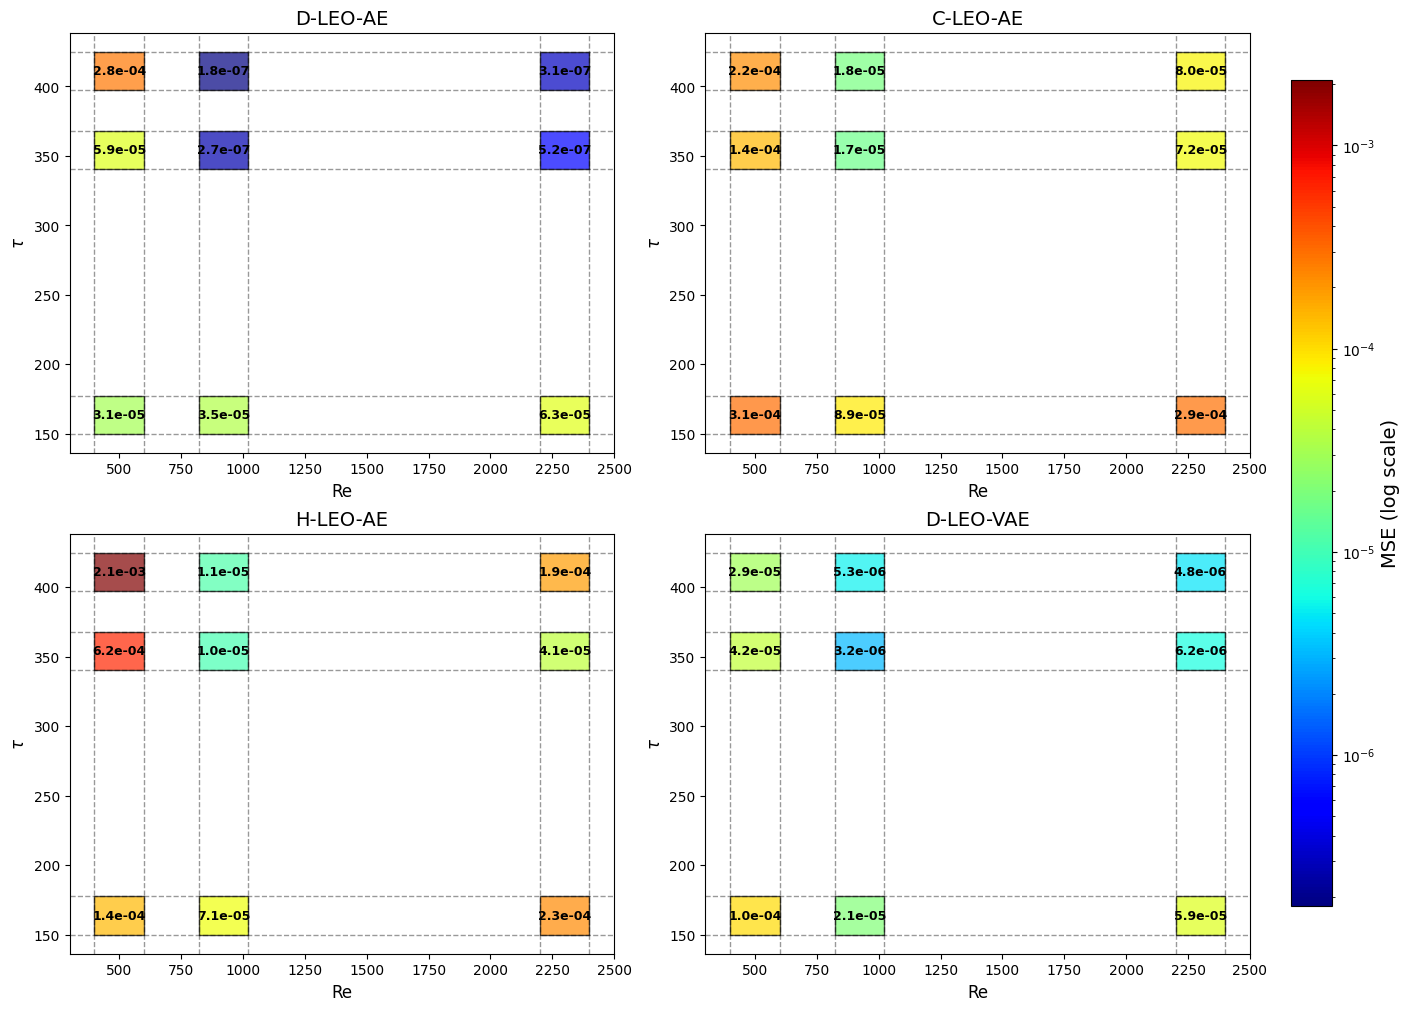

In [4]:
from matplotlib import patches
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm

dt = 2/500
# Evaluate all 4 models on the 3x3 grid
mse_by_model = evaluate_models_on_grid(
    re_interval_split,
    tau_interval_split,
    exact_solution,
    dt,
    predict_fns,
    n_samples= 15_000,        # or whatever you like
    t_range=(0.0, 2.0),
)

# Build global LogNorm across all models/zones
all_mse_vals = [
    v
    for model_dict in mse_by_model.values()
    for v in model_dict.values()
    if np.isfinite(v) and v > 0
]

vmin = min(all_mse_vals)
vmax = max(all_mse_vals)
log_norm = LogNorm(vmin=vmin, vmax=vmax)
cmap = plt.cm.jet


def plot_mse_heatmap_for_model(ax, mse_dict, re_interval_split, tau_interval_split, norm, cmap):
    """
    Draws the 3x3 Re–τ zone MSE heatmap for a single model on a given axes.
    Uses the provided LogNorm `norm` so all subplots share the same scale.
    """
    interval_parts = ['left', 'interp', 'right']

    # Map for convenience
    re_map = {
        'left':  re_interval_split.extrapolation_left,
        'interp': re_interval_split.interpolation,
        'right': re_interval_split.extrapolation_right,
    }
    tau_map = {
        'left':  tau_interval_split.extrapolation_left,
        'interp': tau_interval_split.interpolation,
        'right': tau_interval_split.extrapolation_right,
    }

    # Draw 9 rectangles
    for re_part in interval_parts:
        a_min, a_max = re_map[re_part]
        for tau_part in interval_parts:
            t_min, t_max = tau_map[tau_part]
            key = f"Re_{re_part}-tau_{tau_part}"
            mse = mse_dict.get(key, None)
            if mse is None:
                continue

            color = cmap(norm(mse))
            rect = patches.Rectangle(
                (a_min, t_min),
                a_max - a_min,
                t_max - t_min,
                facecolor=color,
                alpha=0.7,
                edgecolor='black',
                linewidth=1.0,
            )
            ax.add_patch(rect)

            # print MSE in scientific notation inside the cell
            ax.text(
                (a_min + a_max) / 2.0,
                (t_min + t_max) / 2.0,
                f"{mse:.1e}",
                ha='center',
                va='center',
                fontsize=9,
                color='black',
                weight='bold',
            )

    # Draw region boundaries as dashed lines
    re_bounds = sorted([
        *re_interval_split.extrapolation_left,
        *re_interval_split.interpolation,
        *re_interval_split.extrapolation_right,
    ])
    tau_bounds = sorted([
        *tau_interval_split.extrapolation_left,
        *tau_interval_split.interpolation,
        *tau_interval_split.extrapolation_right,
    ])

    for xb in re_bounds:
        ax.axvline(xb, color='black', linestyle='--', linewidth=1.0, alpha=0.4)
    for yb in tau_bounds:
        ax.axhline(yb, color='black', linestyle='--', linewidth=1.0, alpha=0.4)

    ax.set_xlabel("Re", fontsize=12)
    ax.set_ylabel(r"$\tau$", fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)


# Create 2x2 figure, one subplot per model
model_order = ["D-LEO-AE", "C-LEO-AE", "H-LEO-AE", "D-LEO-VAE"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.ravel()

for ax, mname in zip(axes, model_order):
    plot_mse_heatmap_for_model(
        ax,
        mse_by_model[mname],
        re_interval_split,
        tau_interval_split,
        norm=log_norm,
        cmap=cmap,
    )
    ax.set_title(mname, fontsize=14)

# Shared colorbar (log MSE)
sm = ScalarMappable(norm=log_norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes.tolist(),
    location='right',
    fraction=0.035,
    pad=0.02,
)
cbar.set_label("MSE (log scale)", fontsize=14)
cbar.ax.tick_params(labelsize=10)

plt.show()

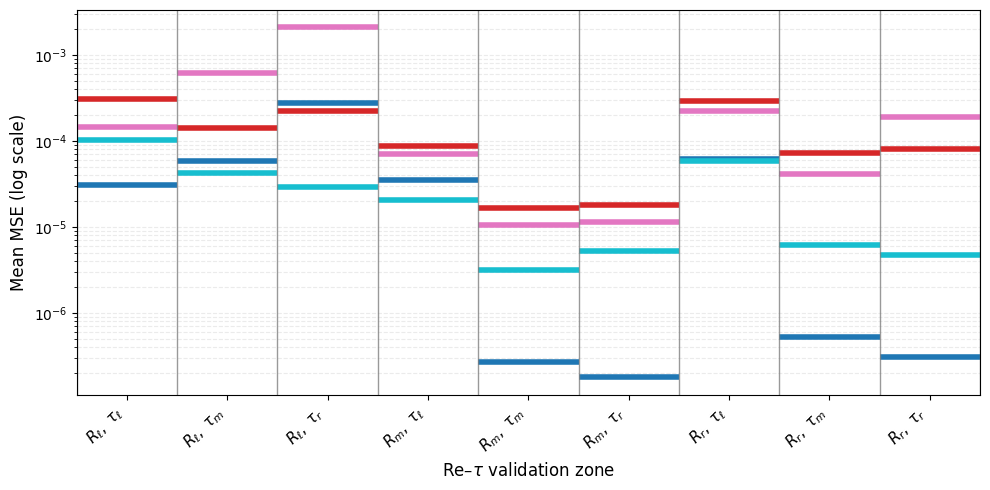

In [5]:
model_order = ["D-LEO-AE", "C-LEO-AE", "H-LEO-AE", "D-LEO-VAE"]

zone_keys = [
    "Re_left-tau_left",
    "Re_left-tau_interp",
    "Re_left-tau_right",
    "Re_interp-tau_left",
    "Re_interp-tau_interp",
    "Re_interp-tau_right",
    "Re_right-tau_left",
    "Re_right-tau_interp",
    "Re_right-tau_right",
]

zone_labels = [
    r"$R_\ell,\ \tau_\ell$",
    r"$R_\ell,\ \tau_m$",
    r"$R_\ell,\ \tau_r$",
    r"$R_m,\ \tau_\ell$",
    r"$R_m,\ \tau_m$",
    r"$R_m,\ \tau_r$",
    r"$R_r,\ \tau_\ell$",
    r"$R_r,\ \tau_m$",
    r"$R_r,\ \tau_r$",
]

n_zones = len(zone_keys)
zone_edges   = np.arange(n_zones + 1)
zone_centers = zone_edges[:-1] + 0.5

fig, ax = plt.subplots(figsize=(10, 5))

colors  = plt.cm.tab10(np.linspace(0, 1, len(model_order)))
handles = []

for mname, color in zip(model_order, colors):
    y_vals = np.array([mse_by_model[mname][k] for k in zone_keys])

    for i, y in enumerate(y_vals):
        # full segment from left to right boundary of the zone
        x0 = zone_edges[i]
        x1 = zone_edges[i+1]

        line = ax.hlines(
            y,
            xmin=x0,
            xmax=x1,
            colors=color,
            linewidth=4.0,      # thicker lines
        )

    handles.append(line)

# vertical zone separators
for x_sep in zone_edges:
    ax.axvline(
        x_sep,
        color="0.5",
        linestyle="-",
        linewidth=1.0,
        alpha=0.8,
    )

ax.set_xlim(0, n_zones)
ax.set_yscale("log")

ax.set_xticks(zone_centers)
ax.set_xticklabels(zone_labels, rotation=45, ha="right", fontsize=11)

ax.set_xlabel("Re–$\\tau$ validation zone", fontsize=12)
ax.set_ylabel("Mean MSE (log scale)", fontsize=12)

ax.grid(True, which="both", linestyle="--", alpha=0.25, axis="y")

# ax.legend(handles=handles, labels=model_order, title="Model", fontsize=12)

fig.tight_layout()

fig.savefig("burgers_evop_zone_mse.png", dpi=300, bbox_inches="tight")
plt.show()

D-LEO-AE      mean MSE = 5.202e-05
C-LEO-AE      mean MSE = 1.377e-04
H-LEO-AE      mean MSE = 3.793e-04
D-LEO-VAE     mean MSE = 3.026e-05


/tmp/ipykernel_15621/1785316555.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = plt.cm.get_cmap("tab10")


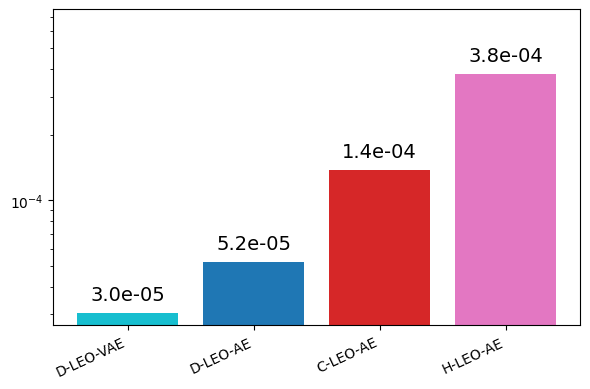

In [6]:
zone_keys = [
    "Re_left-tau_left",
    "Re_left-tau_interp",
    "Re_left-tau_right",
    "Re_interp-tau_left",
    "Re_interp-tau_interp",
    "Re_interp-tau_right",
    "Re_right-tau_left",
    "Re_right-tau_interp",
    "Re_right-tau_right",
]

# Compute and print average MSE over all 9 zones for each model 
avg_mse_by_model = {}
for mname in model_order:
    vals = np.array([mse_by_model[mname][k] for k in zone_keys], dtype=float)
    avg = vals.mean()
    avg_mse_by_model[mname] = avg
    print(f"{mname:12s}  mean MSE = {avg:.3e}")

# Sorting the models
sorted_models = sorted(model_order, key=lambda m: avg_mse_by_model[m])

# Colors consistent with the zone-MSE figure 
tab10 = plt.cm.get_cmap("tab10")
color_indices = {
    "D-LEO-AE": 0,   # blue
    "C-LEO-AE": 3,   # red
    "H-LEO-AE": 6,   # pink-ish / purple
    "D-LEO-VAE": 9,  # cyan-ish
}
color_map = {m: tab10(i) for m, i in color_indices.items()}

# Bar plot
fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(len(sorted_models))
heights = [avg_mse_by_model[m] for m in sorted_models]
bar_colors = [color_map[m] for m in sorted_models]

bars = ax.bar(x, heights, color=bar_colors)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(sorted_models, rotation=25, ha="right")

# give extra headroom so annotations stay inside the axes
ax.set_ylim(top=max(heights) * 2.0)

#ax.axhline(1e-4, color="0.8", linestyle="--", linewidth=1)

# annotate bars with values
for rect, m in zip(bars, sorted_models):
    h = rect.get_height()
    ax.text(
        rect.get_x() + rect.get_width()/2.0,
        h * 1.1,
        f"{h:.1e}",
        ha="center",
        va="bottom",
        fontsize=14,
    )

#ax.set_ylabel("Mean MSE over all Re–$\\tau$ zones")

fig.tight_layout()
fig.savefig("burgers_evop_avg_mse_bar_colored.png", dpi=300, bbox_inches="tight")
plt.show()

## Viualizing the High Dim Field

Re (left extrap) = 481.346
tau_left  = 151.973
tau_right = 413.396
t_init    = 0.150, dt = 4.000e-03

MSEs for chosen configuration:
  Left  zone  (tau=151.973):  AE  = 1.139e-05,  VAE = 4.906e-05
  Right zone  (tau=413.396): AE  = 7.349e-04,  VAE = 1.103e-04


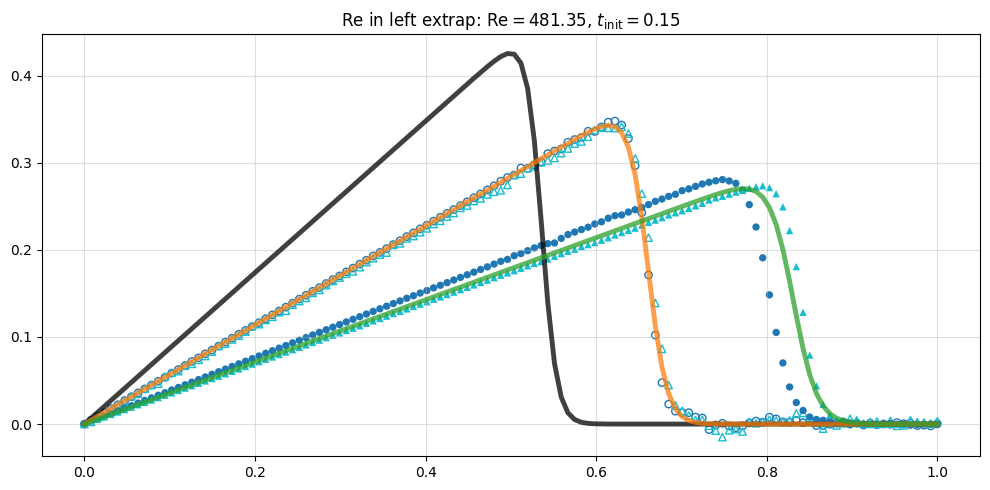

In [7]:
dt = 2/500
t_init = 0.15  # fixed, as requested

# Re from left extrapolation interval
Re_left_min, Re_left_max = re_interval_split.extrapolation_left
Re_val = float(np.random.uniform(Re_left_min, Re_left_max))

# taus: one from left, one from right extrap intervals
tauL_min, tauL_max = tau_interval_split.extrapolation_left
tauR_min, tauR_max = tau_interval_split.extrapolation_right

tau_left  = float(np.random.uniform(tauL_min, tauL_max))
tau_right = float(np.random.uniform(tauR_min, tauR_max))

# Time step
print(f"Re (left extrap) = {Re_val:.3f}")
print(f"tau_left  = {tau_left:.3f}")
print(f"tau_right = {tau_right:.3f}")
print(f"t_init    = {t_init:.3f}, dt = {dt:.3e}")

# Exact solutions
# initial condition
x_init = np.asarray(exact_solution(Re_val, t_init))          # shape (128,)

# ground-truth at t_init + tau*dt
t_L = t_init + tau_left  * dt
t_R = t_init + tau_right * dt

x_exact_L = np.asarray(exact_solution(Re_val, t_L))
x_exact_R = np.asarray(exact_solution(Re_val, t_R))

# Model predictions (Direct AE + Direct VAE)
predict_AE  = predict_fns["D-LEO-AE"]
predict_VAE = predict_fns["D-LEO-VAE"]

x_pred_L_AE  = predict_AE(Re_val, tau_left,  x_init)
x_pred_R_AE  = predict_AE(Re_val, tau_right, x_init)

x_pred_L_VAE = predict_VAE(Re_val, tau_left,  x_init)
x_pred_R_VAE = predict_VAE(Re_val, tau_right, x_init)

# MSEs (for sanity / optional annotation)
mse_L_AE  = mean_squared_error(x_exact_L, x_pred_L_AE)
mse_L_VAE = mean_squared_error(x_exact_L, x_pred_L_VAE)
mse_R_AE  = mean_squared_error(x_exact_R, x_pred_R_AE)
mse_R_VAE = mean_squared_error(x_exact_R, x_pred_R_VAE)

print("\nMSEs for chosen configuration:")
print(f"  Left  zone  (tau={tau_left:.3f}):  AE  = {mse_L_AE:.3e},  VAE = {mse_L_VAE:.3e}")
print(f"  Right zone  (tau={tau_right:.3f}): AE  = {mse_R_AE:.3e},  VAE = {mse_R_VAE:.3e}")


x_grid = np.linspace(0.0,1.0,num=128)
fig, ax = plt.subplots(figsize=(10, 5))

# Colors for consistency
color_exact_L  = "tab:orange"
color_exact_R  = "tab:green"
color_ae       = "tab:blue"
color_vae      = "tab:cyan"

# Lines: IC + exact solutions
ax.plot(x_grid, x_init, "k-", linewidth=3.5,
        label=rf"$x(t_{{\mathrm{{init}}}}={t_init:.2f})$", alpha = 0.75)

ax.plot(x_grid, x_exact_L, "-", color=color_exact_L, linewidth=3.5,
        label=rf"Exact at $t_L$, $\tau_L={tau_left:.2f}$", alpha = 0.75)

ax.plot(x_grid, x_exact_R, "-", color=color_exact_R, linewidth=3.5,
        label=rf"Exact at $t_R$, $\tau_R={tau_right:.2f}$", alpha = 0.75)

# Scatter: model predictions for left extrap
ax.scatter(x_grid, x_pred_L_AE,  s=28, marker="o",  facecolors="none",
           edgecolors=color_ae,
           label=rf"D-EvOp-AE, $\tau_L$ (MSE={mse_L_AE:.1e})")

ax.scatter(x_grid, x_pred_L_VAE, s=28, marker="^", facecolors="none",
           edgecolors=color_vae,
           label=rf"D-EvOp-VAE, $\tau_L$ (MSE={mse_L_VAE:.1e})")

# Scatter: model predictions for right extrap 
ax.scatter(x_grid, x_pred_R_AE,  s=28, marker="o",  facecolors=color_ae,
           edgecolors="none",
           label=rf"D-EvOp-AE, $\tau_R$ (MSE={mse_R_AE:.1e})")

ax.scatter(x_grid, x_pred_R_VAE, s=28, marker="^", facecolors=color_vae,
           edgecolors="none",
           label=rf"D-EvOp-VAE, $\tau_R$ (MSE={mse_R_VAE:.1e})")

# Cosmetics
# ax.set_xlabel("Grid index (or x)")
# ax.set_ylabel("State")
ax.set_title(
    rf"Re in left extrap: $\mathrm{{Re}}={Re_val:.2f}$, "
    rf"$t_{{\mathrm{{init}}}}={t_init:.2f}$"
)

ax.grid(True, alpha=0.4)
# ax.legend(loc="upper right", fontsize=9, ncol=2)

fig.tight_layout()
fig.savefig("burgers_evop_example_profiles_single.png",
            dpi=300, bbox_inches="tight")
plt.show()

### Many to One Decoder $E\big(u(x,t+\tau,\mathrm{Re})\big)$ and $P\big(E(u(x,t,\mathrm{Re}));\,\tau,\mathrm{Re}\big)$ - Qualitative

In [8]:
def _flat2d(z):
    """Ensure latent tensor is (B, m)."""
    if isinstance(z, (tuple, list)):
        z = z[0]
    if z.dim() > 2:
        return z.view(z.size(0), -1)
    return z


class AELEOPlotWrapper(nn.Module):
    """
    Wrapper for AE-based LEO variants (D-LEO-AE / C-LEO-AE / H-LEO-AE),
    where propagation is done via an external propagator.
    """
    def __init__(self, model, propagator):
        super().__init__()
        self.model = model          # backbone with encoder/decoder or LEO wrapper
        self.propagator = propagator

        # try to get encoder/decoder from model
        self.encoder = getattr(model, "encoder", None)
        self.decoder = getattr(model, "decoder", None)

    def encode(self, x):
        if self.encoder is not None:
            z = self.encoder(x)
            return _flat2d(z)
        else:
            # fall back to model forward (x_hat, z)
            x_hat, z = self.model(x)
            return _flat2d(z)

    def decode(self, z):
        """
        z: (B,m) -> x_hat: (B,N)
        """
        return self.decoder(z)

    def propagate_from_x(self, x_t, tau, Re):
        """
        Encode x_t once, propagate z_t with external propagator.
        x_t: (B,1,N) or (B,N)
        tau, Re: (B,1)
        returns z_prop: (B,m)
        """
        # if model forward already gives z_t, use it
        if hasattr(self.model, "forward") and self.encoder is None:
            _, z_t = self.model(x_t)
            z_t = _flat2d(z_t)
        else:
            z_t = self.encode(x_t)

        z_prop = self.propagator(z_t, tau, Re)
        return _flat2d(z_prop)


class DVLEOPlotWrapper(nn.Module):
    """
    Wrapper for Direct LEO with VAE backbone (D-LEO-VAE),
    where the model forward already produces z_tau.
    """
    def __init__(self, leo_model):
        super().__init__()
        self.model = leo_model
        self.encoder = leo_model.encoder
        self.decoder = leo_model.decoder

    def encode(self, x):
        out = self.encoder(x)
        if isinstance(out, (tuple, list)):
            mu = out[0]
        else:
            mu = out
        return _flat2d(mu)

    def decode(self, z):
        return self.decoder(z)

    def propagate_from_x(self, x_t, tau, Re):
        _, _, _, _, z_tau = self.model(x_t, tau, Re)
        return _flat2d(z_tau)

In [9]:
def plot_latents_all_Re(
    wrapper,
    exact_solution,
    Re_values,
    taus,
    t0,
    dt,
    device,
    model_name="LEO"
):
    """
    Left:  Encoded latents of exact u(t+τ) for all Re, all τ.
    Right: Propagated latents from u(t0) for all Re, all τ (colored by τ).
    """
    wrapper.eval()
    taus = taus.view(-1, 1).to(device)                 # (T,1)
    taus_np = taus.squeeze(-1).cpu().numpy()
    T = taus.size(0)

    colors = plt.cm.tab10(np.linspace(0, 1, len(Re_values)))
    markers = ['o', 'o', 's', '^', 'D', 'P', '*', 'X']  # reused cyclically
    cmap = plt.get_cmap('jet')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    for i, Re_val in enumerate(Re_values):
        Re_val = float(Re_val)
        marker = markers[i % len(markers)]
        color = colors[i % len(colors)]

        # many-to-one: start from u(t0)
        x_t = torch.tensor(
            exact_solution(Re_val, t0)[None, None, :],
            dtype=torch.float32, device=device
        )  # (1,1,N)

        # propagate from z(t0) across all τ
        z_prop_list = []
        for tau in taus:
            tau_b = tau.view(1, 1).expand(1, 1).to(device)
            Re_b  = torch.tensor([[Re_val]], dtype=torch.float32, device=device)

            z_prop = wrapper.propagate_from_x(x_t, tau_b, Re_b)  # (1,m)
            z_prop_list.append(z_prop.squeeze(0))
        z_prop_taus = torch.stack(z_prop_list, dim=0)  # (T,m)

        # encoded latents of exact u(t+τ)
        physical_times = t0 + taus_np * dt
        exact_list = [
            torch.tensor(exact_solution(Re_val, float(t)), dtype=torch.float32, device=device)
            for t in physical_times
        ]
        exact_solns = torch.stack(exact_list, dim=0)  # (T,N)

        z_true_list = []
        with torch.no_grad():
            for k in range(T):
                xin = exact_solns[k].unsqueeze(0).unsqueeze(0)  # (1,1,N)
                z_true = wrapper.encode(xin)                    # (1,m)
                z_true_list.append(z_true.squeeze(0))
        z_true_taus = torch.stack(z_true_list, dim=0)  # (T,m)

        actual = z_true_taus[:, :2].detach().cpu().numpy()
        prop   = z_prop_taus[:, :2].detach().cpu().numpy()

        # left: encoded latents of exact
        ax1.scatter(
            actual[:, 0], actual[:, 1],
            color=color, marker=marker,
            label=f'Enc (Re={int(Re_val)})',
            alpha=0.7, s=40
        )

        # right: propagated latents (colored by τ)
        sc = ax2.scatter(
            prop[:, 0], prop[:, 1],
            c=taus_np, cmap=cmap,
            marker=marker, edgecolor=color, linewidth=0.5,
            alpha=0.7, label=f'Prop (Re={int(Re_val)})'
        )

    # formatting
    ax1.set_title(f"{model_name}: Encoded latents of exact $u(t+\\tau)$", fontsize=16)
    ax1.set_xlabel(r"$Z_1$", fontsize=14); ax1.set_ylabel(r"$Z_2$", fontsize=14)
    ax1.tick_params(axis='both', which='major', labelsize=12)
    ax1.grid(alpha=0.3)
    ax1.legend(fontsize=9, loc='upper right', ncol=2)

    ax2.set_title(f"{model_name}: Propagated latents (colored by $\\tau$)", fontsize=16)
    ax2.set_xlabel(r"$Z_1$", fontsize=14); ax2.set_ylabel(r"$Z_2$", fontsize=14)
    ax2.tick_params(axis='both', which='major', labelsize=12)
    ax2.grid(alpha=0.3)
    ax2.legend(fontsize=9, loc='upper right', ncol=2)

    cbar = fig.colorbar(sc, ax=ax2)
    cbar.set_label('τ (index / step)', fontsize=12)

    plt.suptitle("Latent Space Comparison Across Reynolds Numbers", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.25)
    plt.show()

In [10]:
def plot_latent_vs_exact_for_single_Re(
    wrapper,
    exact_solution,
    Re_value,
    taus,
    t0,
    dt,
    device,
    model_name="LEO",
    tau_idx=15,
    save_path=None,
    show=True,
):
    """
    For one Re:
      - Left: IC, exact u(x, t0+τ), and two forecast versions at one τ.
      - Right: latent trajectories (encoded vs propagated) with same τ highlighted.
    """
    wrapper.eval()
    Re_value = float(Re_value)

    taus = taus.view(-1, 1).to(device)          # (T,1)
    taus_np = taus.squeeze(-1).cpu().numpy()    # (T,)
    T = taus.size(0)
    assert 0 <= tau_idx < T, "tau_idx out of range."

    # 1) Initial condition u(x,t0)
    x_t = torch.tensor(
        exact_solution(Re_value, t0)[None, None, :],  # (1,1,N)
        dtype=torch.float32,
        device=device,
    )

    # 2) Propagate from x_t for all τ
    z_prop_list = []
    x_hat_prop_list = []

    with torch.no_grad():
        z_t0 = wrapper.encode(x_t)  # latent of IC, (1,m)

        for tau in taus:
            tau_b = tau.view(1, 1).to(device)
            Re_b  = torch.tensor([[Re_value]], dtype=torch.float32, device=device)

            z_prop = wrapper.propagate_from_x(x_t, tau_b, Re_b)   # (1,m)
            x_hat_tau = wrapper.decode(z_prop)                    # (1,N)

            z_prop_list.append(z_prop.squeeze(0))        # (m,)
            x_hat_prop_list.append(x_hat_tau.squeeze(0)) # (N,)

    z_prop_taus = torch.stack(z_prop_list, dim=0)      # (T,m)
    x_hat_taus  = torch.stack(x_hat_prop_list, dim=0)  # (T,N)

    # 3) Exact u(t0+τ) and encoded+decoded
    physical_times = t0 + taus_np * dt
    exact_list = [
        torch.tensor(
            exact_solution(Re_value, float(tt)),
            dtype=torch.float32,
            device=device,
        )
        for tt in physical_times
    ]
    exact_solns = torch.stack(exact_list, dim=0)  # (T,N)

    z_true_list = []
    x_hat_exact_list = []

    with torch.no_grad():
        for exact_sol in exact_solns:                 # exact_sol: (N,)
            xin = exact_sol.unsqueeze(0).unsqueeze(0)   # (1,1,N)
            z_mu = wrapper.encode(xin)                  # (1,m)
            z_mu = z_mu.squeeze(0)                      # (m,)
            xh   = wrapper.decode(z_mu.unsqueeze(0)).squeeze(0)  # (N,)

            z_true_list.append(z_mu)
            x_hat_exact_list.append(xh)

    z_true_taus  = torch.stack(z_true_list,  dim=0)       # (T,m)
    x_hat_exacts = torch.stack(x_hat_exact_list, dim=0)   # (T,N)

    # 4) Plotting
    x_grid = np.linspace(0.0, 1.0, x_hat_taus.size(1))
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 5))

    # Marker choices, kept consistent across both panels
    encoded_marker     = "D"   # diamond
    propagated_marker  = "o"   # circle
    ic_marker          = "^"   # triangle

    # Left: physical fields 
    # Exact solution at t0+τ (single chosen τ): black line
    axL.plot(
        x_grid,
        exact_solns[tau_idx].detach().cpu().numpy(),
        color="k",
        alpha=0.3,
        linewidth=3.0,
    )

    # Initial condition u(x,t0): gray dashed line
    axL.plot(
        x_grid,
        x_t.squeeze().detach().cpu().numpy(),
        linestyle="--",
        linewidth=2.0,
        color="gray",
    )

    # Propagated forecast at τ: blue scatter
    axL.scatter(
        x_grid,
        x_hat_taus[tau_idx].detach().cpu().numpy(),
        s=22,
        alpha=0.5,
        marker=propagated_marker,
        color="tab:blue",
    )

    # Encoded+decoded exact at τ: orange scatter
    axL.scatter(
        x_grid,
        x_hat_exacts[tau_idx].detach().cpu().numpy(),
        s=40,
        alpha=0.40,
        marker=encoded_marker,
        color="tab:orange",
    )

    axL.set_title(f"{model_name} | Re={Re_value:.0f}, $\\tau$={int(taus_np[tau_idx])}")
    axL.set_xlabel("x")
    axL.set_ylabel("u(x)")
    axL.grid(alpha=0.2)

    # Right: latent trajectories
    actual_means = z_true_taus[:, :2].detach().cpu().numpy()  # encoded E(u(t0+τ))
    prop_means   = z_prop_taus[:, :2].detach().cpu().numpy()  # propagated
    z0_2d = z_t0.detach().cpu().numpy().squeeze()[:2]
    cmap = plt.get_cmap("jet")

    # Encoded trajectory, colored by τ (same marker/color as left)
    sc_encoded = axR.scatter(
        actual_means[:, 0],
        actual_means[:, 1],
        c=taus_np,
        cmap=cmap,
        alpha=0.9,
        marker=encoded_marker,
        s=60,
    )

    # Thin line through encoded trajectory
    axR.plot(
        actual_means[:, 0],
        actual_means[:, 1],
        color="k",
        linewidth=0.6,
        alpha=0.4,
    )

    # Propagated trajectory
    axR.scatter(
        prop_means[:, 0],
        prop_means[:, 1],
        c=taus_np,
        cmap=cmap,
        alpha=0.9,
        marker=propagated_marker,
        edgecolors="none",
        s=60,
    )

    # Latent of IC, filled triangle
    axR.scatter(
        z0_2d[0],
        z0_2d[1],
        s=120,
        marker=ic_marker,
        facecolors="tab:green",
        edgecolors="k",
        linewidths=1.5,
    )

    # Highlight chosen τ (bigger markers)
    enc_pt  = actual_means[tau_idx]
    prop_pt = prop_means[tau_idx]

    axR.scatter(
        enc_pt[0],
        enc_pt[1],
        s=280,
        marker=encoded_marker,
        facecolors="none",
        edgecolors="k",
        linewidths=2.0,
    )
    axR.scatter(
        prop_pt[0],
        prop_pt[1],
        s=280,
        marker=propagated_marker,
        facecolors="none",
        edgecolors="k",
        linewidths=2.0,
    )

    axR.set_title(f"{model_name}: latent space\n(highlighted: same $\\tau$ as left)")
    axR.set_xlabel(r"$Z_1$")
    axR.set_ylabel(r"$Z_2$")
    axR.grid(alpha=0.2)

    # Thicken the plot boxes
    for ax in (axL, axR):
        for spine in ax.spines.values():
            spine.set_linewidth(1.8)

    # Colorbar for τ (using encoded trajectory)
    cbar = fig.colorbar(sc_encoded, ax=axR)
    cbar.set_label(r"$\tau$ (index / step)", fontsize=12)

    plt.tight_layout()

    # ----- save / show -----
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if not show:
        plt.close(fig)

    return save_path

'D_LEO_AE_latent_phys.png'

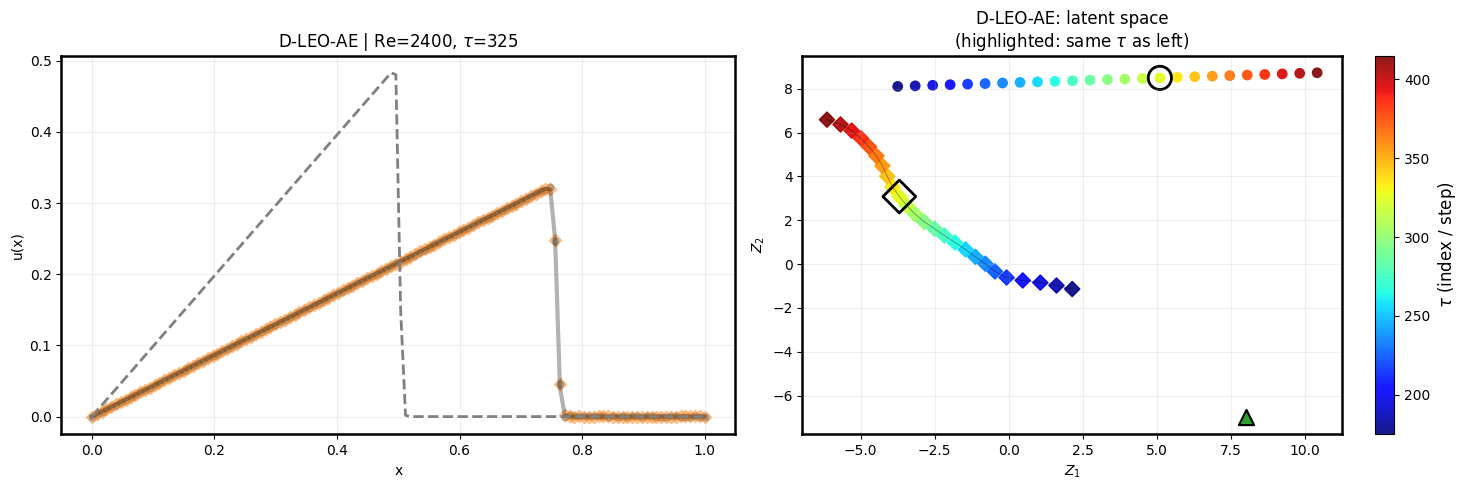

In [11]:
t0   = 0.01
Re_value = 2400
dt   = 2.0 / 500.0
taus = torch.arange(175, 425, step=10, dtype=torch.float32)

wrap_d_ae = AELEOPlotWrapper(leo_d_ae, leo_d_ae.propagator)

plot_latent_vs_exact_for_single_Re(
    wrap_d_ae,
    exact_solution,
    Re_value=Re_value,
    taus=taus,
    t0=t0,
    dt=dt,
    device=DEVICE,
    model_name="D-LEO-AE",
    tau_idx=15,
    save_path="D_LEO_AE_latent_phys.png",
)

'C_LEO_AE_latent_phys.png'

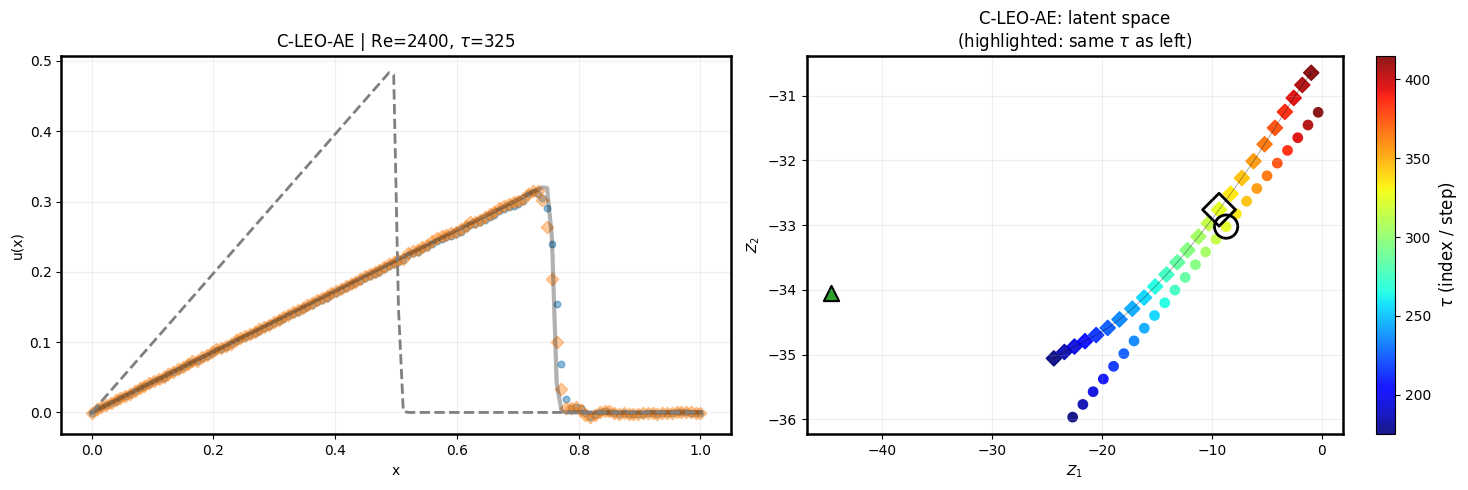

In [12]:
# AE-based models - Align Model
wrap_a_ae = AELEOPlotWrapper(leo_c_ae, leo_c_ae.propagator)

plot_latent_vs_exact_for_single_Re(
    wrap_a_ae,
    exact_solution,
    Re_value=Re_value,
    taus=taus,
    t0=t0,
    dt=dt,
    device=DEVICE,
    model_name="C-LEO-AE",
    tau_idx=15,
    save_path="C_LEO_AE_latent_phys.png",
)

'H_LEO_AE_latent_phys.png'

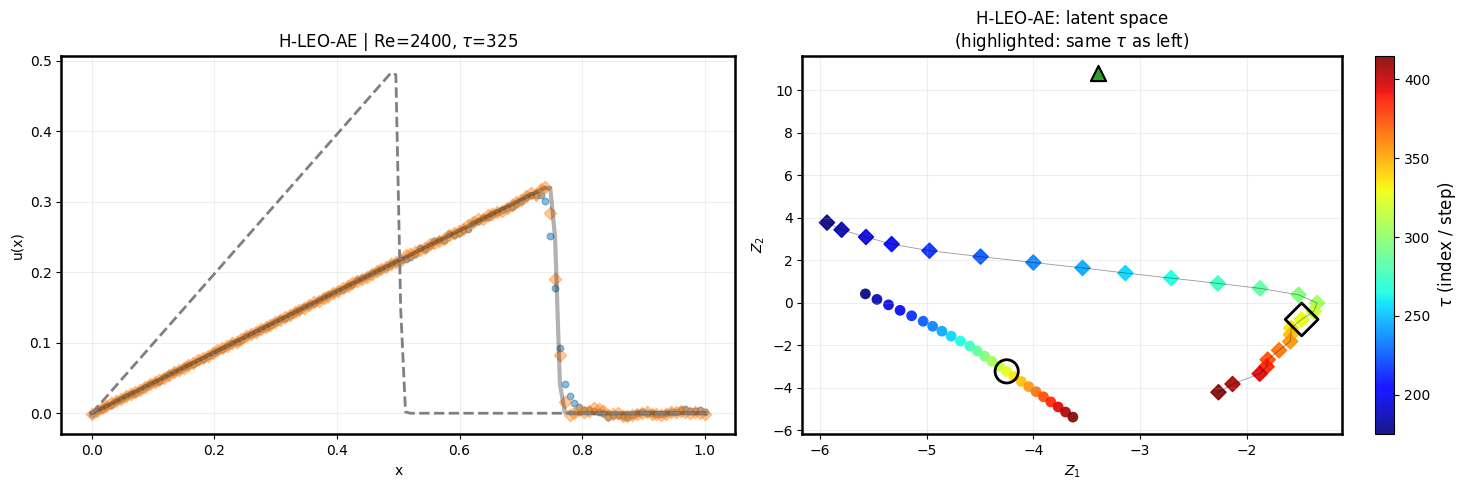

In [13]:
# AE-based models - Hybrid Model
wrap_h_ae = AELEOPlotWrapper(leo_h_ae, leo_h_ae.propagator)

plot_latent_vs_exact_for_single_Re(
    wrap_h_ae,
    exact_solution,
    Re_value=Re_value,
    taus=taus,
    t0=t0,
    dt=dt,
    device=DEVICE,
    model_name="H-LEO-AE",
    tau_idx=15,
    save_path="H_LEO_AE_latent_phys.png",
)

'D_LEO_VAE_latent_phys.png'

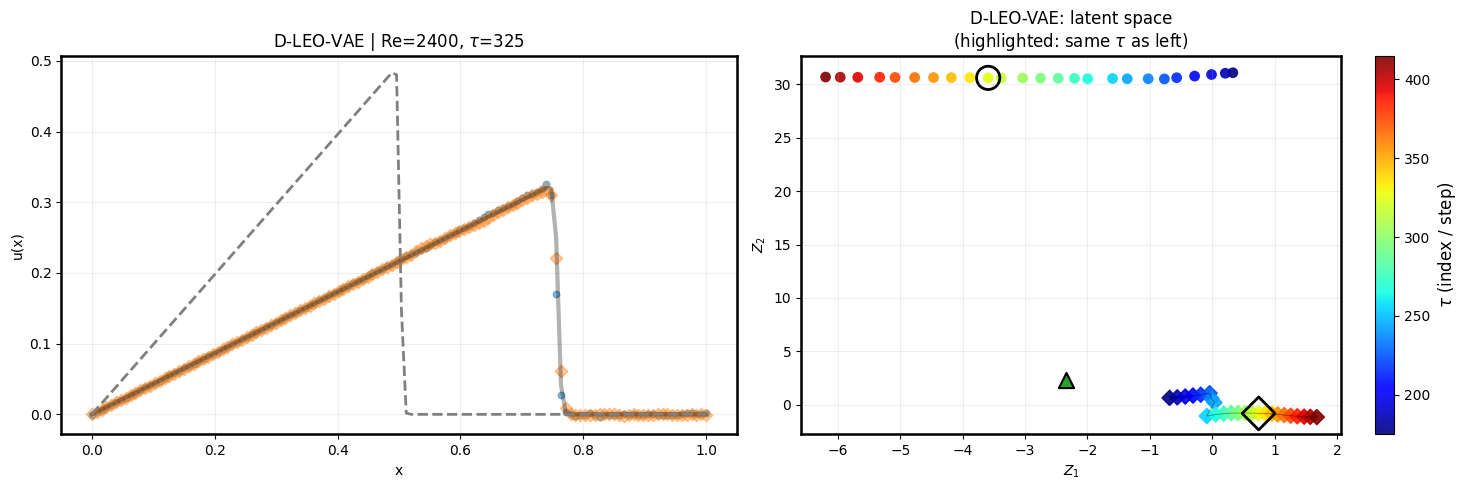

In [14]:
# Example: instantiate + load weights (use your own get_model / load_model_weights)
leo_d_vae_model = get_model(128, 2, Propagator_C)              # <- instance
leo_d_vae_model = load_model_weights(leo_d_vae_model, leo_d_vae_pth).to(DEVICE)
leo_d_vae_model.eval()

# Wrap the INSTANCE (not the class)
wrap_d_vae = DVLEOPlotWrapper(leo_d_vae_model)

plot_latent_vs_exact_for_single_Re(
    wrap_d_vae,
    exact_solution,
    Re_value=Re_value,
    taus=taus,
    t0=t0,
    dt=dt,
    device=DEVICE,
    model_name="D-LEO-VAE",
    tau_idx=15,
    save_path="D_LEO_VAE_latent_phys.png",
)

### Latent-space separation between $E\big(u(x,t+\tau,\mathrm{Re})\big)$ and $P\big(E(u(x,t,\mathrm{Re}));\,\tau,\mathrm{Re}\big)$ - Quantitative Metric!

In [15]:
# example: instantiate + load weights
leo_d_vae_model = get_model(128, 2, Propagator_C)
leo_d_vae_model = load_model_weights(leo_d_vae_model, leo_d_vae_pth).to(DEVICE)
leo_d_vae_model.eval()

# wrapper gets the INSTANCE
wrap_d_vae = DVLEOPlotWrapper(leo_d_vae_model)

In [16]:
# 1) Metric: average latent distance
def compute_avg_latent_distance(
    wrapper,
    exact_solution,
    Re_values,
    taus_base,
    t0_list,
    dt,
    device,
    t_max=2.0,
):
    """
    For a given wrapper (model) compute the average L2 distance
    between

        E(u(t0 + τ*dt))         -- "true" latent at target time
    and P(E(u(t0)), τ, Re)      -- propagated latent from t0

    averaged over all combinations of:
        Re in Re_values
        t0 in t0_list
        τ in taus_base
    such that t0 + τ*dt <= t_max.
    """
    wrapper.eval()

    distances = []
    n_pairs = 0

    Re_values = [float(r) for r in Re_values]

    with torch.no_grad():
        for t0 in t0_list:
            t0 = float(t0)

            # filter taus so final time stays within [0, t_max]
            valid_taus = [float(tau) for tau in taus_base
                          if t0 + tau * dt <= t_max + 1e-8]
            if len(valid_taus) == 0:
                continue

            for Re_val in Re_values:
                # IC: u(x, t0)
                u_t0 = exact_solution(Re_val, t0)          # (N,)
                x_t  = torch.tensor(
                    u_t0[None, None, :],
                    dtype=torch.float32,
                    device=device,
                )

                for tau in valid_taus:
                    tau_tensor = torch.tensor([[tau]], dtype=torch.float32, device=device)
                    Re_tensor  = torch.tensor([[Re_val]], dtype=torch.float32, device=device)

                    # propagated latent from t0
                    z_prop = wrapper.propagate_from_x(x_t, tau_tensor, Re_tensor)
                    z_prop = z_prop.view(-1)  # (m,)

                    # exact field at t0 + τ*dt
                    t_target = t0 + tau * dt
                    u_target = exact_solution(Re_val, t_target)  # (N,)
                    x_target = torch.tensor(
                        u_target[None, None, :],
                        dtype=torch.float32,
                        device=device,
                    )

                    # encoded latent of exact field
                    z_true = wrapper.encode(x_target).view(-1)  # (m,)

                    # L2 distance in latent space
                    d = torch.norm(z_true - z_prop, p=2).item()
                    distances.append(d)
                    n_pairs += 1

    if n_pairs == 0:
        mean_dist = float("nan")
    else:
        mean_dist = float(np.mean(distances))

    print(f"Used {n_pairs} (Re, t0, tau) combinations.")
    return mean_dist, np.array(distances)

# 2) Driver: compute for all 4 models
dt   = 2.0 / 500.0
taus_base = np.arange(175, 425, 5, dtype=float)       # τ indices
Re_values = np.arange(400, 2600, 100, dtype=float)    # 400,600,...,2500
t0_list   = [0.25, 0.50, 0.75, 1.00, 1.25]            # starting times

# >>> UPDATED NAMES ONLY: EvOp -> LEO, A -> C
model_wrappers = {
    "D-LEO-AE":  AELEOPlotWrapper(leo_d_ae,  leo_d_ae.propagator),
    "C-LEO-AE":  AELEOPlotWrapper(leo_c_ae,  leo_c_ae.propagator),
    "H-LEO-AE":  AELEOPlotWrapper(leo_h_ae,  leo_h_ae.propagator),
    "D-LEO-VAE": DVLEOPlotWrapper(leo_d_vae_model),   # <-- THIS
}


mean_dists = {}
all_dists  = {}

for name, wrapper in model_wrappers.items():
    print(f"\nComputing latent distance metric for {name} ...")
    mean_d, d_array = compute_avg_latent_distance(
        wrapper        = wrapper,
        exact_solution = exact_solution,
        Re_values      = Re_values,
        taus_base      = taus_base,
        t0_list        = t0_list,
        dt             = dt,
        device         = DEVICE,
        t_max          = 2.0,
    )
    mean_dists[name] = mean_d
    all_dists[name]  = d_array
    print(f"  Mean latent distance for {name}: {mean_d:.4e}")


Computing latent distance metric for D-LEO-AE ...
Used 3036 (Re, t0, tau) combinations.
  Mean latent distance for D-LEO-AE: 1.6227e+01

Computing latent distance metric for C-LEO-AE ...
Used 3036 (Re, t0, tau) combinations.
  Mean latent distance for C-LEO-AE: 7.4867e-01

Computing latent distance metric for H-LEO-AE ...
Used 3036 (Re, t0, tau) combinations.
  Mean latent distance for H-LEO-AE: 1.3555e+00

Computing latent distance metric for D-LEO-VAE ...
Used 3036 (Re, t0, tau) combinations.
  Mean latent distance for D-LEO-VAE: 2.0293e+01


/tmp/ipykernel_15621/1710343016.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = plt.cm.get_cmap("tab10")


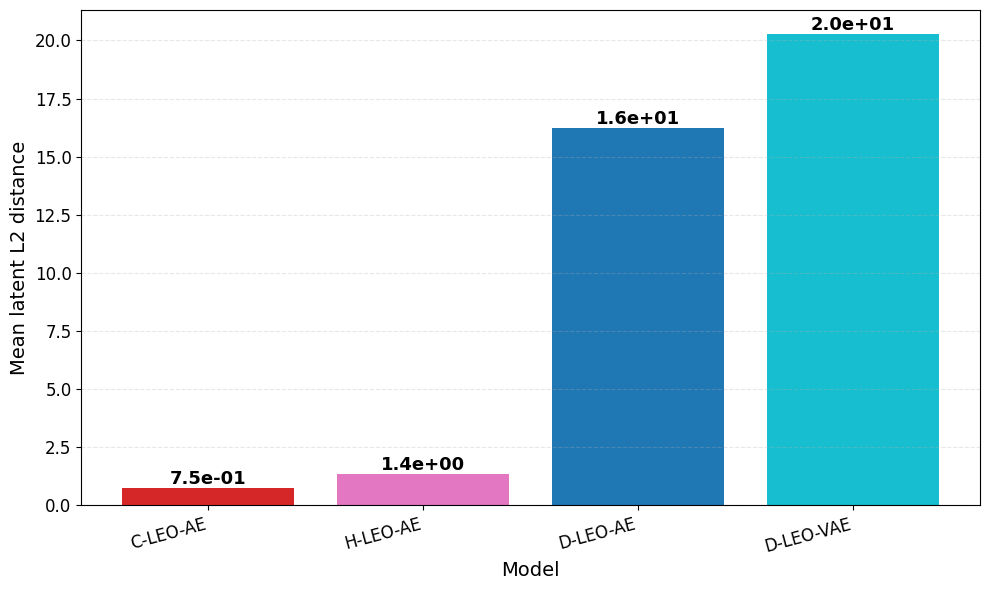

In [17]:
plt.figure(figsize=(10, 6))  # a bit taller

names = list(mean_dists.keys())
vals  = np.array([mean_dists[n] for n in names], dtype=float)

# sort by increasing mean distance (ignore NaNs by pushing them to the end)
order = np.argsort(np.nan_to_num(vals, nan=np.inf))
names = [names[i] for i in order]
vals  = vals[order]

# fixed color indices per model (using tab10)
tab10 = plt.cm.get_cmap("tab10")
color_indices = {
    "D-LEO-AE": 0,   # blue
    "C-LEO-AE": 3,   # red   (was A- align, now C- consistent)
    "H-LEO-AE": 6,   # purple-ish
    "D-LEO-VAE": 9,  # cyan-ish
}

colors = [
    tab10(color_indices[m]) if m in color_indices else "gray"
    for m in names
]

bars = plt.bar(names, vals, color=colors)

plt.ylabel("Mean latent L2 distance", fontsize=14)
plt.xlabel("Model", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.xticks(fontsize=12, rotation=15, ha="right")
plt.yticks(fontsize=12)

# annotate values on top of each bar
for b, v in zip(bars, vals):
    label = "nan" if not np.isfinite(v) else f"{v:.1e}"
    plt.text(
        b.get_x() + b.get_width() / 2.0,
        b.get_height() if np.isfinite(v) else 0.0,
        label,
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("mean_l2_latents.png", dpi=300, bbox_inches="tight")
plt.show()

## Intermediate Observations:

In [18]:
# Define predict-fn FIRST (and no .eval() inside predict_fn)
def make_predict_fn_leo_d_vae(model, device):
    model = model.to(device)
    model.eval()

    def predict_fn(Re_val, tau_steps, x_t):
        x_t_tensor = torch.tensor(x_t, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)  # (1,1,128)
        tau_tensor = torch.tensor([[tau_steps]], dtype=torch.float32, device=device)                  # (1,1)
        Re_tensor  = torch.tensor([[Re_val]],  dtype=torch.float32, device=device)                    # (1,1)

        with torch.no_grad():
            out = model(x_t_tensor, tau_tensor, Re_tensor)

        # expected: x_hat_t, x_hat_tau, mean, log_var, z_tau
        x_hat_tau = out[1] if isinstance(out, (tuple, list)) else out
        return x_hat_tau.squeeze().detach().cpu().numpy()

    return predict_fn


# Instantiate + load weights (make sure THIS is an instance)
leo_d_vae_model = get_model(128, 2, Propagator_C)
leo_d_vae_model = load_model_weights(leo_d_vae_model, leo_d_vae_pth).to(device)
leo_d_vae_model.eval()

print("leo_d_vae_model type:", type(leo_d_vae_model))
print("is nn.Module instance:", isinstance(leo_d_vae_model, torch.nn.Module))

pred_fn = make_predict_fn_leo_d_vae(leo_d_vae_model, device)

leo_d_vae_model type: <class 'model_v2.Model'>
is nn.Module instance: True


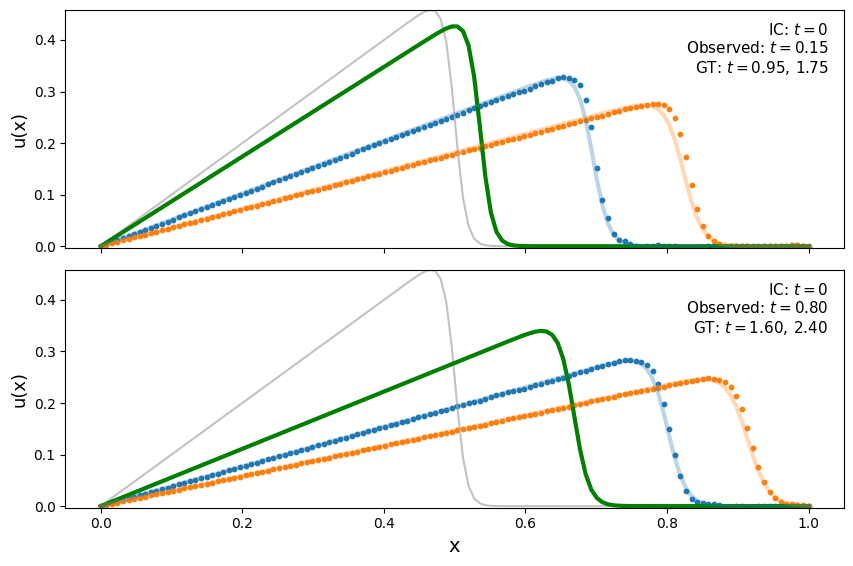

In [19]:
Re_val = 500.0
# Horizons: offsets from the anchor, in *time steps*
horizons = [200, 400]

# Physical anchor times
anchor_times_phys = [0.15, 0.80]   # physical time units
anchor_labels = [rf"anchor $t={t:.2f}$" for t in anchor_times_phys]

# Global initial condition at t = 0, for context
u0 = exact_solution(Re_val, 0.0)

# precompute fields to set global y-limits
all_fields = [u0]
gt_cache   = {}   # (row_idx, h) -> gt
pred_cache = {}   # (row_idx, h) -> pred

for row_idx, t_anchor in enumerate(anchor_times_phys):
    u_anchor = exact_solution(Re_val, t_anchor)
    all_fields.append(u_anchor)

    for h in horizons:
        t_target = t_anchor + h * dt

        gt = exact_solution(Re_val, t_target)
        gt_cache[(row_idx, h)] = gt
        all_fields.append(gt)

        pred = pred_fn(Re_val, h, u_anchor)  # tau_val is in STEPS here (h)
        pred_cache[(row_idx, h)] = pred
        all_fields.append(pred)

ymin = min(f.min() for f in all_fields)
ymax = max(f.max() for f in all_fields)

# plotting 
fig, axs = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for row_idx, (ax, t_anchor, anchor_label) in enumerate(zip(axs, anchor_times_phys, anchor_labels)):
    u_anchor = exact_solution(Re_val, t_anchor)

    # IC at t=0 in light gray
    ax.plot(x_grid, u0, color="0.7", alpha=0.8, linewidth=1.5)

    # anchor state in green (observed state)
    ax.plot(x_grid, u_anchor, color="green", linewidth=3.0)

    colors = ["C0", "C1"]
    target_phys_times = []

    for c, h in zip(colors, horizons):
        gt   = gt_cache[(row_idx, h)]
        pred = pred_cache[(row_idx, h)]
        t_target = t_anchor + h * dt
        target_phys_times.append(t_target)

        # GT
        ax.plot(x_grid, gt, color=c, linewidth=3.0, alpha=0.30)

        # prediction markers
        ax.scatter(x_grid, pred, s=10, color=c)

    ax.set_ylim(ymin, ymax)
    ax.set_ylabel("u(x)", fontsize=13)
    ax.grid(False)

    # annotation
    t1, t2 = target_phys_times
    text = (
        r"IC: $t=0$" + "\n"
        + rf"Observed: $t={t_anchor:.2f}$" + "\n"
        + rf"GT: $t={t1:.2f},\, {t2:.2f}$"
    )
    ax.text(
        0.98, 0.95, text,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, lw=0.0),
    )

axs[-1].set_xlabel("x", fontsize=14)

plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.98])
plt.savefig("initial_observation_vary.png", dpi=300, bbox_inches="tight")
plt.show()
